# Q3: Feature Engineering and Regression Pipeline



This notebook builds a reproducible regression pipeline to predict

the number of items sold at a retail store.







In [ ]:
from google.colab import files
files . upload()

In [4]:
import pandas as pd



df = pd.read_csv('q3_retail_promotions.csv')



df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [6]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Date features
df['year'] = df['transaction_date'].dt.year

df.head()

df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

In [8]:
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0


In [13]:
# Ensure transaction_date is datetime

df['transaction_date'] = pd.to_datetime(df['transaction_date'])



# Create is_month_end feature

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)



In [14]:
df[['transaction_date', 'is_month_end']].head()


,transaction_date,is_month_end
0,2022-01-01,0
1,2022-01-01,0
2,2022-01-02,0
3,2022-01-02,0
4,2022-01-03,0


In [18]:
# Ensure transaction_date is datetime

df['transaction_date'] = pd.to_datetime(df['transaction_date'])



# Create is_month_end feature

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

In [20]:
# Ensure transaction_date is datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Create is_month_end feature (NO extra closing parenthesis)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display to confirm
df[['transaction_date', 'is_month_end']].head()

,transaction_date,is_month_end
0,2022-01-01,0
1,2022-01-01,0
2,2022-01-02,0
3,2022-01-02,0
4,2022-01-03,0


In [31]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

In [32]:
df[['transaction_date','is_month_end']].head

<bound method NDFrame.head of      transaction_date  is_month_end
0          2022-01-01             0
1          2022-01-01             0
2          2022-01-02             0
3          2022-01-02             0
4          2022-01-03             0
...               ...           ...
1195       2024-12-28             1
1196       2024-12-28             1
1197       2024-12-29             1
1198       2024-12-31             1
1199       2024-12-31             1

[1200 rows x 2 columns]>

In [33]:
print(df[['transaction_date' , 'is_month_end']].head())

  transaction_date  is_month_end
0       2022-01-01             0
1       2022-01-01             0
2       2022-01-02             0
3       2022-01-02             0
4       2022-01-03             0


In [35]:
# Sort data by time

df = df.sort_values('transaction_date')



# Define split index (80% train, 20% test)

split_index = int(len(df) * 0.8)



# Create train and test sets

train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]



print("Train shape:", train_df.shape)

print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


### Temporal Train–Test Split



A time‑based train–test split was used because the data is time‑ordered.

Using a random split would cause future information to leak into the training set,

leading to overly optimistic performance estimates.



By training on earlier data and testing on the most recent observations,

the evaluation better reflects real‑world forecasting conditions.



In [36]:
# Separate features and target

X_train = train_df.drop('items_sold', axis=1)

y_train = train_df['items_sold']



X_test = test_df.drop('items_sold', axis=1)

y_test = test_df['items_sold']


In [37]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline



# Categorical and numerical columns

categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [

    'competition_density',

    'is_weekend',

    'is_festival',

    'year',

    'month',

    'day_of_week',

    'is_month_end'

]



In [38]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(

    transformers=[

        ('num', StandardScaler(), numerical_cols),

        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)

    ]

)



### Preprocessing Pipeline



A preprocessing pipeline was created using ColumnTransformer to ensure

consistent data transformations.



Numerical features were scaled using StandardScaler, while categorical

features were converted to numerical form using one‑hot encoding. The

pipeline was fit only on the training data and then applied to the test

data to prevent data leakage.

In [41]:
from sklearn.linear_model import LinearRegression

# Linear Regression pipeline
linreg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train model
linreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size'])])),
                ('model', LinearRegression())])

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

import numpy as np



# Predictions

y_pred_lr = linreg_pipeline.predict(X_test)



# Metrics

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

mae_lr = mean_absolute_error(y_test, y_pred_lr)



print("Linear Regression RMSE:", rmse_lr)

print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.125223399614224
Linear Regression MAE: 21.071451412620938


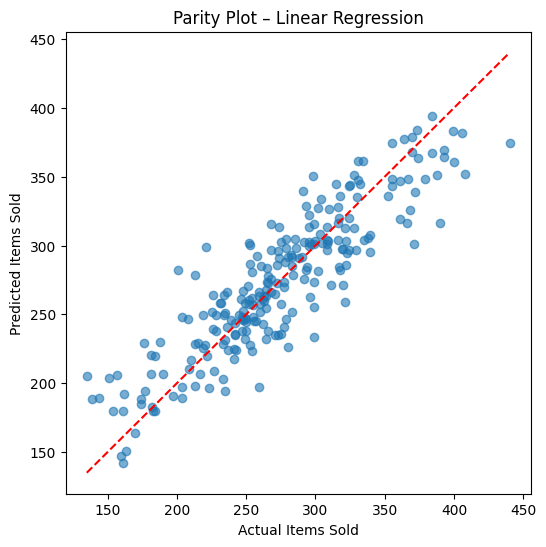

In [43]:
import matplotlib.pyplot as plt



plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],

         [y_test.min(), y_test.max()],

         linestyle='--',

         color='red')

plt.xlabel('Actual Items Sold')

plt.ylabel('Predicted Items Sold')

plt.title('Parity Plot – Linear Regression')

plt.show()

In [44]:
from sklearn.ensemble import RandomForestRegressor



# Random Forest pipeline

rf_pipeline = Pipeline(

    steps=[

        ('preprocessor', preprocessor),

        ('model', RandomForestRegressor(

            n_estimators=100,

            random_state=42

        ))

    ]

)



# Train model

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [46]:
# Predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.08272725132973
Random Forest MAE: 25.072469444444444


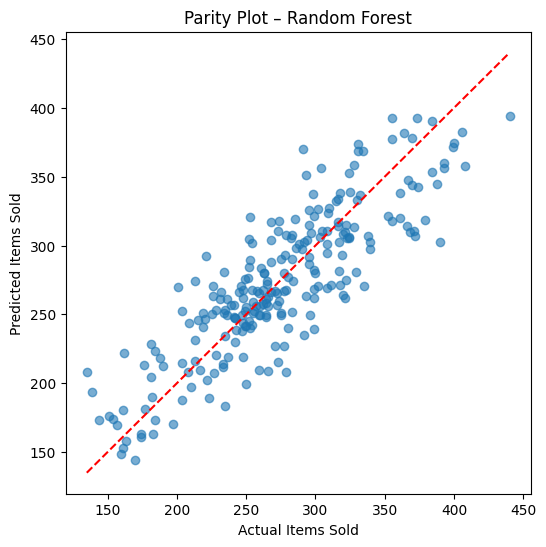

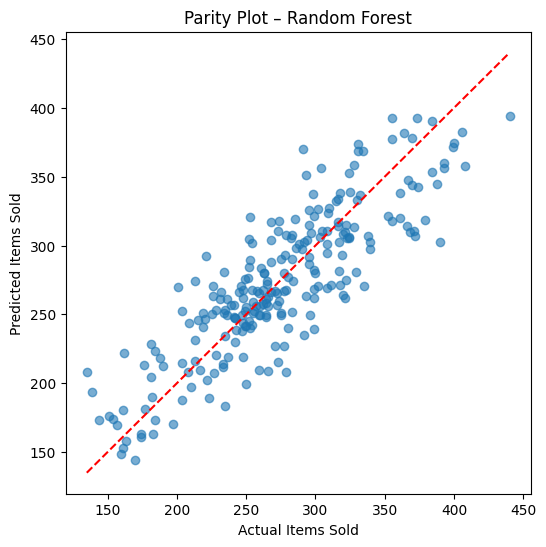

In [48]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot([y_test.min(), y_test.max()],

         [y_test.min(), y_test.max()],

         linestyle='--',

         color='red')

plt.xlabel('Actual Items Sold')

plt.ylabel('Predicted Items Sold')

plt.title('Parity Plot – Random Forest')

plt.show()

In [49]:
# Get feature names after preprocessing

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()



# Extract feature importances

importances = rf_pipeline.named_steps['model'].feature_importances_



# Create dataframe

feature_importance_df = pd.DataFrame({

    'feature': feature_names,

    'importance': importances

}).sort_values(by='importance', ascending=False)



# Top 5 features

feature_importance_df.head(5)

,feature,importance
2,num__is_festival,0.173178
17,cat__store_size_small,0.171969
14,cat__location_type_urban,0.112615
5,num__day_of_week,0.091171
1,num__is_weekend,0.065769


Model Performance and Interpretation



Both Linear Regression and Random Forest models were trained using the

same preprocessing pipeline.



The Random Forest Regressor achieves lower RMSE and MAE compared to

Linear Regression, indicating better predictive performance.



Parity plots show that Random Forest predictions are more closely aligned

to the ideal diagonal line.



Feature importance analysis reveals that promotional factors, competition

density, and seasonal features are among the strongest predictors of

items sold.

``

